In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.models as tv_models
from torchmetrics.classification import Accuracy, F1Score, Precision, Recall

import matplotlib.pyplot as plt
import IPython.display as display

from tqdm import tqdm

import gradio as gr
from PIL import Image

import os

C:\Users\sanuja\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using: {device}')

Using: cuda


In [4]:
dataset_dir = './dataset'
train_dir = os.path.join(dataset_dir, 'train')
val_dir = os.path.join(dataset_dir, 'valid')
test_dir = os.path.join(dataset_dir, 'test')

In [5]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_transforms = transforms.Compose([
    transforms.Resize((224,244)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [6]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_transforms)

In [7]:
classes = train_dataset.classes
num_classes = len(classes)

print(test_dataset.class_to_idx)

{'Crazing': 0, 'Inclusion': 1, 'Patches': 2, 'Pitted': 3, 'Rolled': 4, 'Scratches': 5}


In [21]:
def display_tensor(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img = tensor * std + mean
    img = torch.clamp(img, 0, 1)

    img = img.permute(1, 2, 0)
    plt.imshow(img)
    plt.axis('off')
    plt.show

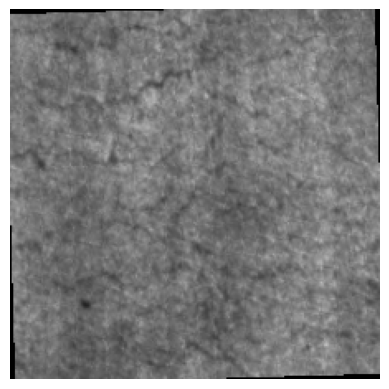

In [22]:
img_tensor, _ = train_dataset[0]
display_tensor(img_tensor)

In [23]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [41]:
model = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)

In [28]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [42]:
in_features = model.fc.in_features

class CustomResNet50Classifier(nn.Module):
    def __init__(self, in_features, num_classes):
        super(CustomResNet50Classifier, self).__init__()
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 256),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        out = self.classifier(x)
        return out

model.fc = CustomResNet50Classifier(in_features, num_classes)
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [43]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [44]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

In [56]:
train_metrics = {
    "acc": Accuracy(task='multiclass', num_classes=num_classes).to(device),
    "f1": F1Score(task='multiclass', num_classes=num_classes).to(device),
    "precision": Precision(task='multiclass', num_classes=num_classes).to(device),
    "recall": Recall(task='multiclass', num_classes=num_classes).to(device)
}

val_metrics = {
    "acc": Accuracy(task='multiclass', num_classes=num_classes).to(device),
    "f1": F1Score(task='multiclass', num_classes=num_classes).to(device),
    "precision": Precision(task='multiclass', num_classes=num_classes).to(device),
    "recall": Recall(task='multiclass', num_classes=num_classes).to(device)
}

test_metrics = {
    "acc": Accuracy(task='multiclass', num_classes=num_classes).to(device),
    "f1": F1Score(task='multiclass', num_classes=num_classes).to(device),
    "precision": Precision(task='multiclass', num_classes=num_classes).to(device),
    "recall": Recall(task='multiclass', num_classes=num_classes).to(device)
}

In [50]:
def reset_metrics(metrics):
    for m in metrics.values():
        m.reset()

def update_metrics(metrics, preds, targets):
    for m in metrics.values():
        m.update(preds, targets)

def compute_metrics(metrics):
    return {name: m.compute().item() for name, m in metrics.items()}

In [55]:
epochs = 5
for epoch in range(epochs):
    print(f"{epoch + 1}/{epochs} epochs")
    model.train()
    reset_metrics(train_metrics)

    train_loss = 0.0

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        out = model(images)
        loss = criterion(out, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(out, dim=1)
        update_metrics(train_metrics, preds, labels)

    train_results = compute_metrics(train_metrics)

    model.eval()
    reset_metrics(val_metrics)

    val_loss = 0.0
    
    for images, labels in tqdm(val_loader):
        images = images.to(device)
        labels = labels.to(device)

        out = model(images)
        loss = criterion(out, labels)
        val_loss += loss.item()

        preds = torch.argmax(out, dim=1)
        update_metrics(val_metrics, preds, labels)
    val_results = compute_metrics(val_metrics)

    print(f"\nEpoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Acc: {train_results['acc']:.4f} | "
          f"Prec: {train_results['precision']:.4f} | "
          f"Rec: {train_results['recall']:.4f} | "
          f"F1: {train_results['f1']:.4f}")

    print(f"Val   Loss: {val_loss/len(val_loader):.4f} | "
          f"Acc: {val_results['acc']:.4f} | "
          f"Prec: {val_results['precision']:.4f} | "
          f"Rec: {val_results['recall']:.4f} | "
          f"F1: {val_results['f1']:.4f}")

1/5 epochs


100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 11.35it/s]



Epoch [1/5]
Train Loss: 0.2192 | Acc: 0.9209 | Prec: 0.9209 | Rec: 0.9209 | F1: 0.9209
Val   Loss: 0.0285 | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000
2/5 epochs


100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 10.82it/s]



Epoch [2/5]
Train Loss: 0.1731 | Acc: 0.9408 | Prec: 0.9408 | Rec: 0.9408 | F1: 0.9408
Val   Loss: 0.0726 | Acc: 0.9861 | Prec: 0.9861 | Rec: 0.9861 | F1: 0.9861
3/5 epochs


...


Epoch [3/5]
Train Loss: 0.1978 | Acc: 0.9318 | Prec: 0.9318 | Rec: 0.9318 | F1: 0.9318
Val   Loss: 0.0387 | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000
4/5 epochs


100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 10.75it/s]



Epoch [4/5]
Train Loss: 0.2971 | Acc: 0.9058 | Prec: 0.9058 | Rec: 0.9058 | F1: 0.9058
Val   Loss: 0.0169 | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000
5/5 epochs


100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 10.64it/s]


Epoch [5/5]
Train Loss: 0.1892 | Acc: 0.9354 | Prec: 0.9354 | Rec: 0.9354 | F1: 0.9354
Val   Loss: 0.0161 | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000


In [57]:
model.eval()
reset_metrics = reset_metrics(test_metrics)
test_loss = 0.0

for images, labels in tqdm(test_loader):
    images = images.to(device)
    labels = labels.to(device)

    out = model(images)
    loss = criterion(out, labels)
    test_loss += loss.item()

    preds = torch.argmax(out, dim=1)
    update_metrics(test_metrics, preds, labels)
test_results = compute_metrics(test_metrics)

print(f"Test   Loss: {test_loss/len(test_loader):.4f} | "
      f"Acc: {test_results['acc']:.4f} | "
      f"Prec: {test_results['precision']:.4f} | "
      f"Rec: {test_results['recall']:.4f} | "
      f"F1: {test_results['f1']:.4f}")

100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.24it/s]

Test   Loss: 0.0483 | Acc: 0.9861 | Prec: 0.9861 | Rec: 0.9861 | F1: 0.9861


In [58]:
torch.save({
    'model_state_dict': model.state_dict()
}, 'metal_surface_defect_detector.pth')

In [71]:
def predict_image(image: Image.Image):
    input_tensor = val_transforms(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_label = classes[pred_idx]
        confidence = probs[0, pred_idx].item()
    return image, f"{pred_label} ({confidence*100:.2f}%)"

In [72]:
iface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs=[gr.Image(type="pil"), gr.Textbox()],
    title="ResNet50 Custom Classifier",
    description="Upload an image and get the predicted class"
)

iface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7865

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


Traceback (most recent call last):
  File "C:\Users\sanuja\AppData\Local\Programs\Python\Python312\Lib\site-packages\gradio\queueing.py", line 766, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sanuja\AppData\Local\Programs\Python\Python312\Lib\site-packages\gradio\route_utils.py", line 355, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sanuja\AppData\Local\Programs\Python\Python312\Lib\site-packages\gradio\blocks.py", line 2147, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sanuja\AppData\Local\Programs\Python\Python312\Lib\site-packages\gradio\blocks.py", line 1629, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sanuja\AppData\Lo